[reference](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [4]:
import sklearn
print(sklearn.__version__)

1.7.1


> 1. Number of Trees
- "n_estimators"

- Number of decision trees in the forest

```python 
RandomForestClassifier(n_estimators=100)
```

--------

> 2. Tree Depth Control
- max_depth
- Maximum depth of each tree
```python
max_depth=5
```
* Effect:
- Small depth → underfitting (high bias)
- Large depth → overfitting (high variance)

------

>  3. Feature Sampling
- max_features
- Number of features considered at each split
```python
max_features='sqrt'   # default for classification
```
*Options:*
- 'sqrt' → √(total features) ✅ (default)
- 'log2'
- integer (fixed number)
- float (percentage)
  > Effect:
- Lower → more randomness → less overfitting
- Higher → less randomness → more overfitting

-------

> 4. Minimum Samples to Split
- "min_samples_split"

- Minimum samples required to split a node
```python 
min_samples_split=2
```
> Effect:
- Higher → simpler trees
- Lower → complex trees

  ---------

> 5. Minimum Samples at Leaf
- "min_samples_leaf"
- Minimum samples required at a leaf node
```python 
min_samples_leaf=1
```
*Effect:*
> Higher → smoother model
> Prevents overfitting
---------

> 6. Bootstrap Sampling
- "bootstrap"
- Whether to use sampling with replacement
```python 
bootstrap=True
```
- True → Random Forest behavior
- False → uses full dataset
- Whether bootstrap samples are used when building trees. If False, the whole dataset is used to build each tree.

-------

> 7. Out-of-Bag Score (Important)
- "oob_score"
- Uses unused samples for validation
```python 
oob_score=True
```
> Gives internal validation score without test set

--------

8. Criterion (Split Quality)

criterion
Measure for split quality


criterion='gini'   # default

Options:

- gini
- entropy
- log_loss

---------

# example

In [5]:
import numpy as np 
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split

X,y = make_classification(
    n_samples=1000,
    n_features = 10 ,
    n_informative = 8,
    n_redundant =2, 
    random_state=42
)

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Default model
rf_default = RandomForestClassifier(random_state=42)
rf_default.fit(X_train, y_train)

y_pred_default = rf_default.predict(X_test)

print("Default Accuracy:", accuracy_score(y_test, y_pred_default))

Default Accuracy: 0.87


In [12]:
rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    max_features='sqrt',
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf_tuned.fit(X_train, y_train)

y_pred_tuned = rf_tuned.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_tuned))

Tuned Accuracy: 0.855


In [13]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid,
    cv=5,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 100}


In [14]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)

print("Best Model Accuracy:", accuracy_score(y_test, y_pred_best))

Best Model Accuracy: 0.865


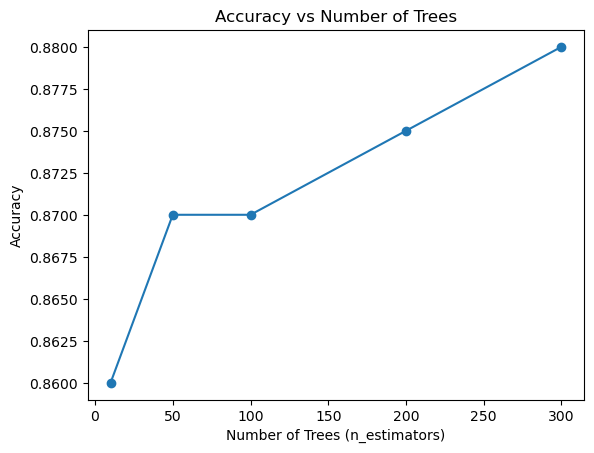

In [15]:
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

n_estimators_list = [10, 50, 100, 200, 300]
scores = []

for n in n_estimators_list:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    
    y_pred = rf.predict(X_test)
    scores.append(accuracy_score(y_test, y_pred))

plt.figure()
plt.plot(n_estimators_list, scores, marker='o')

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Number of Trees")

plt.show()

---------

[regressionClassifierRefrence](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)